In [318]:
# 1. Import Libraries
# 2. Load Dataset
# 3. Exploratory Data Analysis (EDA)
# 4. Data Cleaning & Preprocessing
# 5. Feature Engineering
# 6. User Profile Creation
# 7. Rule-based Matching
# 8. NLP Matching
# 9. Weighted Scoring
# 10. Final Recommendation System

# Import Libraries

In [319]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load Dataset

In [320]:
df = pd.read_csv("../data/job_posts_93.csv")

df.head()

,company_name,job_title,role_category,company_sector,city,region,technical_skills_required,employment_type,work_mode,experience_required_years,education_required,English_required_level,Danish_required_level,salary_min_dkk_monthly,salary_max_dkk_monthly,experience_level,soft_skills_required
0,Digital AI Studio ApS,Junior Data Engineer Intern,Data Engineer,Technology,Odense,Southern Denmark,"SQL Basics, Excel, Git, Python Basics, Data Cl...",Internship,Hybrid,0,Bachelor's Degree,Intermediate,Basic,40000,50000,Entry Level,"Problem Solving, Collaboration, Attention to D..."
1,Nordic AI Studio ApS,ML/AI,ML/AI,Technology,Copenhagen,Capital Region,"Python, Scikit-learn, Model Deployment, ML Pip...",Full-time,Hybrid,2,Master's Degree,Advanced,Danish not required,55000,65000,Mid Level,"Critical Thinking, Research Mindset, Problem S..."
2,Odense DataWorks ApS,Senior Data Engineer,Data Engineer,Technology,Odense,Southern Denmark,"Apache Spark, Kafka, Python, SQL, Data Archite...",Full-time,On-site,6,Master's Degree,Fluent,Basic,62000,72000,Senior Level,"Leadership, Ownership, Stakeholder Communicati..."
3,Cloud Design ApS,Product Analyst,Data Analyst,Technology,Aalborg,North Denmark,"SQL, Excel, Power BI, Product Analytics, Data ...",Full-time,On-site,4,Bachelor's Degree,Advanced,Basic,55000,65000,Senior Level,"Communication, Analytical Thinking, Problem So..."
4,Copenhagen Solutions ApS,UX/UI Designer,UX,Consulting,Copenhagen,Capital Region,"Figma, Adobe XD, Wireframing, Prototyping, Use...",Full-time,Hybrid,2,Master's Degree,Advanced,Intermediate,48000,58000,Mid Level,"Creativity, Communication, Empathy, Collaborat..."


#  Exploratory Data Analysis (EDA)

In [321]:
df.shape

(93, 17)

In [322]:
df.columns

Index(['company_name', 'job_title', 'role_category', 'company_sector', 'city',
       'region', 'technical_skills_required', 'employment_type', 'work_mode',
       'experience_required_years', 'education_required',
       'English_required_level', 'Danish_required_level',
       'salary_min_dkk_monthly', 'salary_max_dkk_monthly', 'experience_level',
       'soft_skills_required'],
      dtype='object')

In [323]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   company_name               93 non-null     object
 1   job_title                  93 non-null     object
 2   role_category              93 non-null     object
 3   company_sector             93 non-null     object
 4   city                       93 non-null     object
 5   region                     93 non-null     object
 6   technical_skills_required  93 non-null     object
 7   employment_type            93 non-null     object
 8   work_mode                  93 non-null     object
 9   experience_required_years  93 non-null     int64 
 10  education_required         93 non-null     object
 11  English_required_level     93 non-null     object
 12  Danish_required_level      93 non-null     object
 13  salary_min_dkk_monthly     93 non-null     int64 
 14  salary_max_d

In [324]:
df.isna().sum()

company_name                 0
job_title                    0
role_category                0
company_sector               0
city                         0
region                       0
technical_skills_required    0
employment_type              0
work_mode                    0
experience_required_years    0
education_required           0
English_required_level       0
Danish_required_level        0
salary_min_dkk_monthly       0
salary_max_dkk_monthly       0
experience_level             0
soft_skills_required         0
dtype: int64

In [325]:
df["role_category"].value_counts()

role_category
DevOps           22
Data Analyst     22
BI               20
ML/AI            12
Data Engineer    11
UX                6
Name: count, dtype: int64

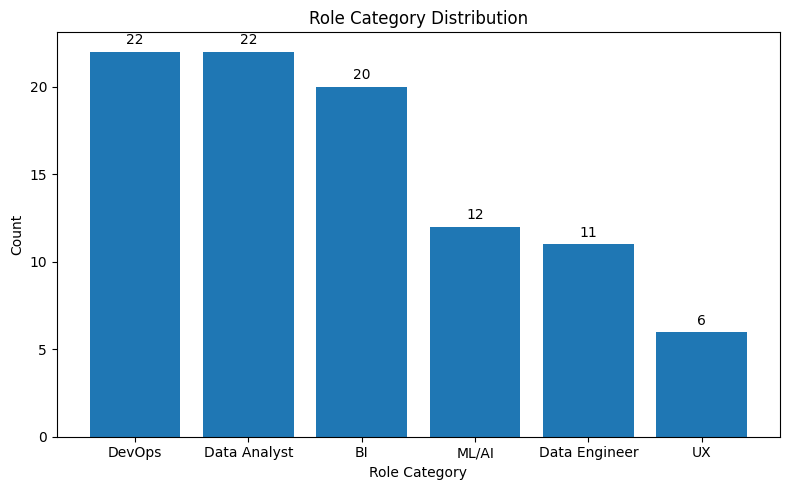

In [326]:

role_counts = df[
    "role_category"
].value_counts()

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    role_counts.index,
    role_counts.values
)

# Add values on top of bars
ax.bar_label(
    bars,
    padding=3
)

ax.set_title("Role Category Distribution")
ax.set_xlabel("Role Category")
ax.set_ylabel("Count")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

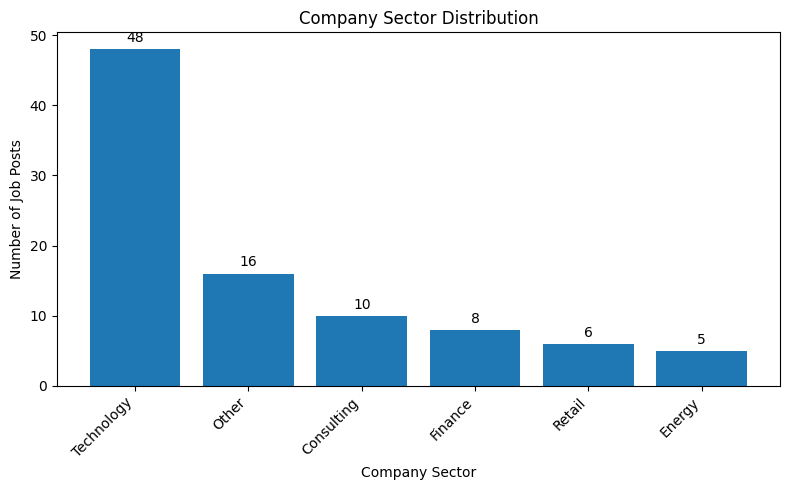

In [327]:
# Group rare sectors
sector_counts = df["company_sector"].value_counts()

rare_sectors = sector_counts[
    sector_counts < 3
].index

df["company_sector"] = df[
    "company_sector"
].replace(
    rare_sectors,
    "Other"
)

# Recalculate counts
sector_counts = df[
    "company_sector"
].value_counts()

# Create plot
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    sector_counts.index,
    sector_counts.values
)

# Add numbers on bars
ax.bar_label(
    bars,
    padding=3
)

ax.set_title("Company Sector Distribution")
ax.set_xlabel("Company Sector")
ax.set_ylabel("Number of Job Posts")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [328]:
df["city"].value_counts()

city
Copenhagen    47
Aarhus        19
Odense        15
Aalborg        5
Esbjerg        3
Vejle          1
Randers        1
Herlev         1
Ballerup       1
Name: count, dtype: int64

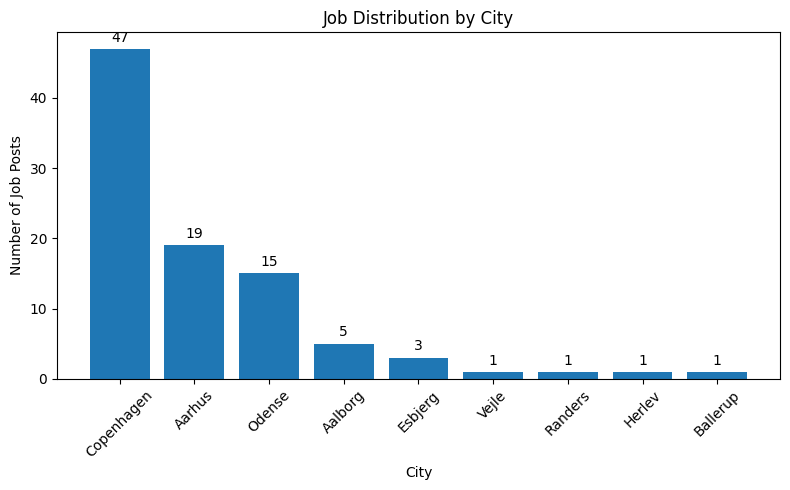

In [329]:
city_counts = df["city"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    city_counts.index,
    city_counts.values
)

# Add values on top of bars
ax.bar_label(
    bars,
    padding=3
)

ax.set_title("Job Distribution by City")
ax.set_xlabel("City")
ax.set_ylabel("Number of Job Posts")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [330]:
df["employment_type"].value_counts()

employment_type
Full-time     73
Part-time     14
Internship     6
Name: count, dtype: int64

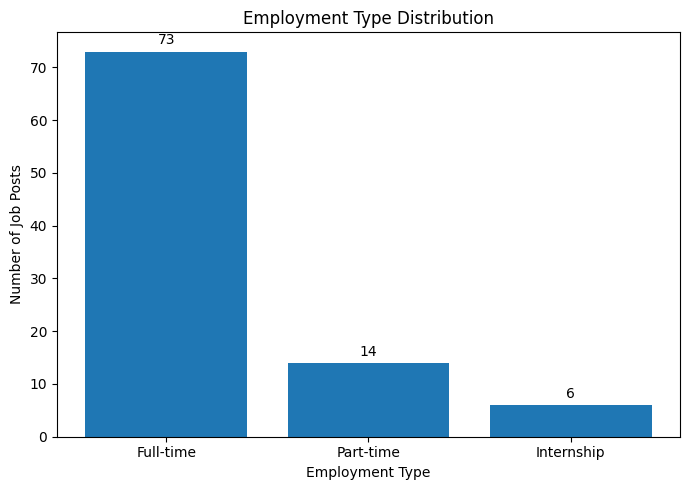

In [331]:
employment_counts = df[
    "employment_type"
].value_counts()

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    employment_counts.index,
    employment_counts.values
)

# Add labels on bars
ax.bar_label(
    bars,
    padding=3
)

ax.set_title("Employment Type Distribution")
ax.set_xlabel("Employment Type")
ax.set_ylabel("Number of Job Posts")

plt.tight_layout()

plt.show()

In [332]:
df["work_mode"].value_counts()

work_mode
Hybrid     58
Remote     18
On-site    17
Name: count, dtype: int64

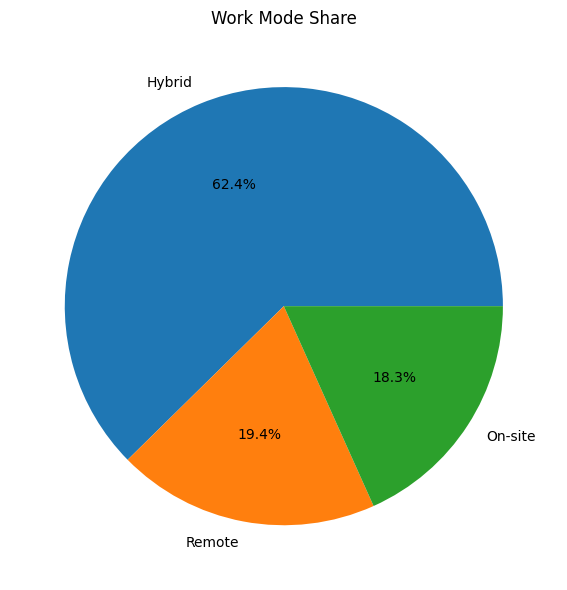

In [333]:
plt.figure(figsize=(6,6))

df["work_mode"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Work Mode Share")
plt.ylabel("")

plt.tight_layout()

plt.show()

In [334]:
df["education_required"].value_counts()

education_required
Bachelor's Degree    70
Master's Degree      22
PhD                   1
Name: count, dtype: int64

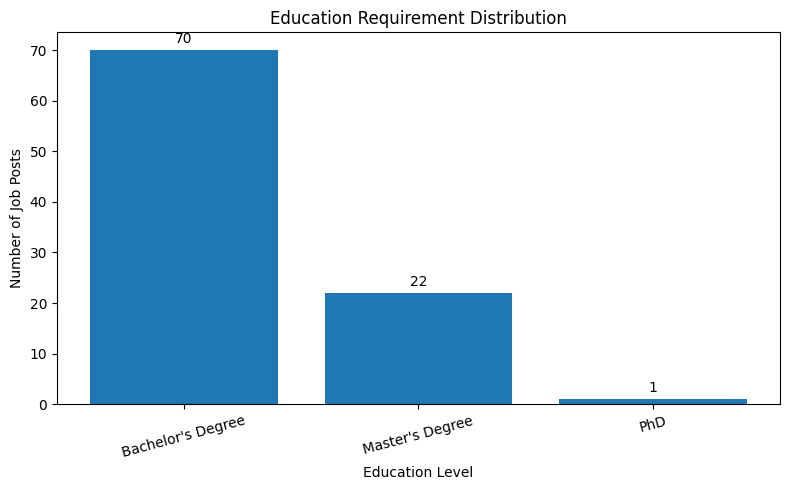

In [335]:
education_counts = df[
    "education_required"
].value_counts()

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    education_counts.index,
    education_counts.values
)

# Add labels
ax.bar_label(
    bars,
    padding=3
)

ax.set_title("Education Requirement Distribution")
ax.set_xlabel("Education Level")
ax.set_ylabel("Number of Job Posts")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

In [336]:
df["experience_required_years"].describe()

count    93.000000
mean      2.666667
std       1.562699
min       0.000000
25%       2.000000
50%       3.000000
75%       4.000000
max       6.000000
Name: experience_required_years, dtype: float64

In [337]:
df["experience_level"] = pd.cut(
    df["experience_required_years"],
    bins=[-1, 1, 3, 6],
    labels=[
        "Entry Level",
        "Mid Level",
        "Senior Level"
    ]
)
df["experience_level"].value_counts()

experience_level
Mid Level       40
Senior Level    30
Entry Level     23
Name: count, dtype: int64

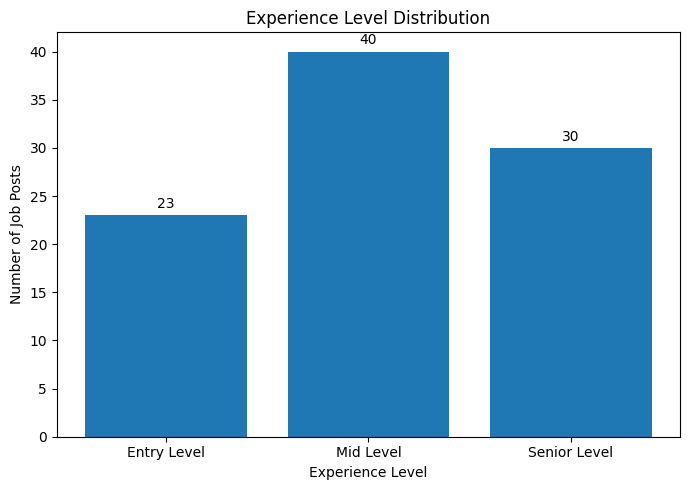

In [338]:
experience_order = [
    "Entry Level",
    "Mid Level",
    "Senior Level"
]

experience_counts = df[
    "experience_level"
].value_counts().reindex(
    experience_order
)

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    experience_counts.index,
    experience_counts.values
)

ax.bar_label(
    bars,
    padding=3
)

ax.set_title("Experience Level Distribution")
ax.set_xlabel("Experience Level")
ax.set_ylabel("Number of Job Posts")

plt.tight_layout()

plt.show()

In [339]:
df["English_required_level"].value_counts()

English_required_level
Advanced        52
Intermediate    29
Fluent          12
Name: count, dtype: int64

In [340]:
df["Danish_required_level"].value_counts()

Danish_required_level
Danish not required    34
Basic                  31
Intermediate           28
Name: count, dtype: int64

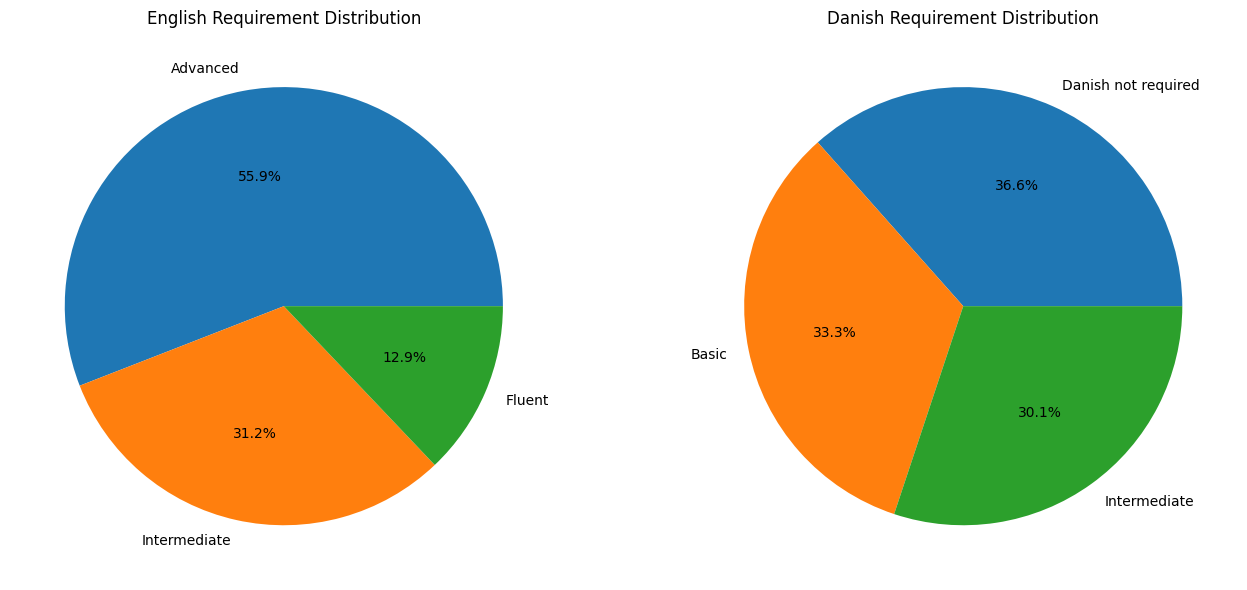

In [341]:
# Count values
english_counts = df[
    "English_required_level"
].value_counts()

danish_counts = df[
    "Danish_required_level"
].value_counts()

# Create figure with 2 subplots
fig, axes = plt.subplots(
    1, 2,
    figsize=(14,6)
)

# English pie chart
axes[0].pie(
    english_counts.values,
    labels=english_counts.index,
    autopct="%1.1f%%"
)

axes[0].set_title(
    "English Requirement Distribution"
)

# Danish pie chart
axes[1].pie(
    danish_counts.values,
    labels=danish_counts.index,
    autopct="%1.1f%%"
)

axes[1].set_title(
    "Danish Requirement Distribution"
)

plt.tight_layout()

plt.show()

In [342]:
df[
    [
        "salary_min_dkk_monthly",
        "salary_max_dkk_monthly"
    ]
].describe()

,salary_min_dkk_monthly,salary_max_dkk_monthly
count,93.000000,93.000000
mean,50741.935484,60806.451613
std,9148.417808,9150.027399
min,35000.000000,45000.000000
25%,45000.000000,55000.000000
50%,55000.000000,65000.000000
75%,55000.000000,65000.000000
max,65000.000000,75000.000000


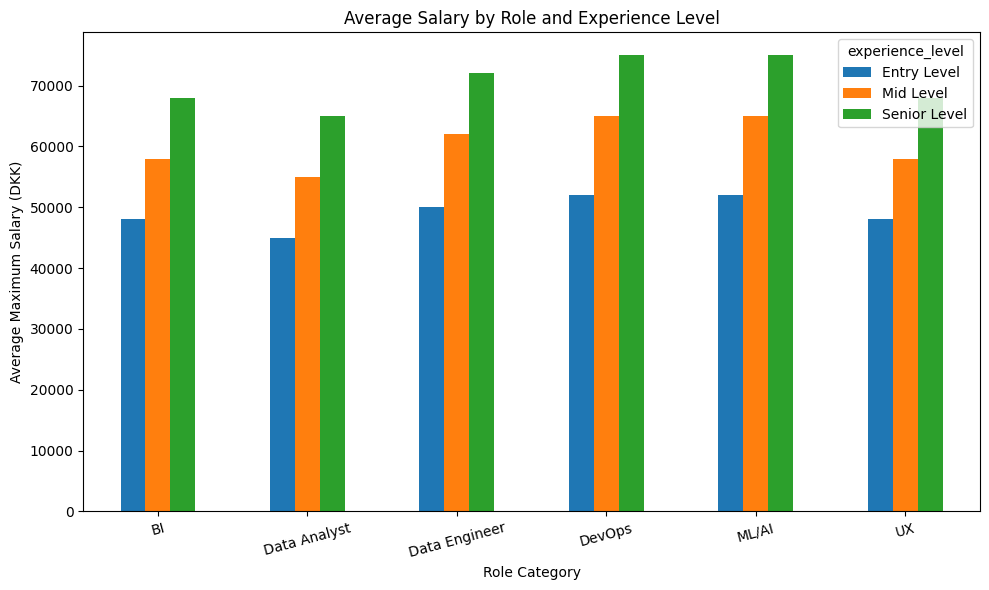

In [343]:
salary_summary = df.groupby(
    ["role_category", "experience_level"]
)["salary_max_dkk_monthly"].mean().unstack()

salary_summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Salary by Role and Experience Level")
plt.xlabel("Role Category")
plt.ylabel("Average Maximum Salary (DKK)")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Data Cleaning & Preprocessing

## Data Cleaning
- Handle missing values
- Remove duplicate rows
- Fix inconsistent values

In [344]:
# Handle missing values

df.isnull().sum()

company_name                 0
job_title                    0
role_category                0
company_sector               0
city                         0
region                       0
technical_skills_required    0
employment_type              0
work_mode                    0
experience_required_years    0
education_required           0
English_required_level       0
Danish_required_level        0
salary_min_dkk_monthly       0
salary_max_dkk_monthly       0
experience_level             0
soft_skills_required         0
dtype: int64

In [345]:
# Remove duplicate rows

df.duplicated().sum()

np.int64(0)

In [346]:
df["technical_skills_required"]

0     SQL Basics, Excel, Git, Python Basics, Data Cl...
1     Python, Scikit-learn, Model Deployment, ML Pip...
2     Apache Spark, Kafka, Python, SQL, Data Archite...
3     SQL, Excel, Power BI, Product Analytics, Data ...
4     Figma, Adobe XD, Wireframing, Prototyping, Use...
5     Excel, SQL Basics, Power BI, Data Cleaning, Go...
6     Power BI, Excel, A/B Testing, SQL, Data Visual...
7     SQL, Excel, Power BI, Data Visualization, Repo...
8     Python, TensorFlow, PyTorch, Scikit-learn, SQL...
9     Power BI, SQL, Reporting, Data Analysis, Busin...
10    Power BI, Data Cleaning, Data Visualization, B...
11    Python, TensorFlow, PyTorch, NLP, Computer Vis...
12    Figma, Adobe XD, Wireframing, Prototyping, Use...
13    Python, TensorFlow, Computer Vision, Deep Lear...
14    SQL, Excel, Data Analysis, Data Visualization,...
15    Docker, AWS, SQL, Python, Apache Spark, Airflo...
16    SQL, Excel, Advanced Excel, Data Analysis, Dat...
17    SQL, Excel, Data Cleaning, Data Visualizat

# Text Normalization
- Convert text to lowercase
- Remove extra spaces
- Normalize skill names
- Remove punctuation

In [347]:
# Text Normalization
tech_all_skills = (
    df["technical_skills_required"]
    .str.lower()
    .str.split(",")
    .explode()
    .str.strip()
)

pd.set_option(
    "display.max_rows",
    None
)

tech_all_skills.value_counts().head(20)

technical_skills_required
sql                       59
excel                     43
power bi                  41
data visualization        39
python                    37
docker                    34
linux                     29
dashboard development     28
git                       27
data analysis             26
terraform                 24
aws                       23
kubernetes                23
data cleaning             23
business intelligence     23
data modeling             21
bash scripting            18
tableau                   18
kpi analysis              17
infrastructure as code    17
Name: count, dtype: int64

In [348]:
tech_skill_counts = (
    tech_all_skills
    .value_counts()
    .reset_index()
)

tech_skill_counts.columns = [
    "skill",
    "count"
]

tech_skill_counts.head(10)

,skill,count
0,sql,59
1,excel,43
2,power bi,41
3,data visualization,39
4,python,37
5,docker,34
6,linux,29
7,dashboard development,28
8,git,27
9,data analysis,26


In [349]:
tech_skill_counts[["skill"]].to_csv(
    "../data/technical_skills.csv",
    index=False
)

In [350]:
tech_skills_by_role = (
    df.groupby("role_category")["technical_skills_required"]
    .apply(lambda x:
        x.str.lower()
         .str.split(",")
         .explode()
         .str.strip()
         .value_counts()
    )
)

tech_skills_by_role

role_category                               
BI             sql                              20
               power bi                         19
               excel                            18
               data visualization               17
               business intelligence            15
               dashboard development            13
               data modeling                    12
               dax                              10
               tableau                           6
               power query                       6
               etl processes                     6
               reporting solutions               5
               data cleaning                     5
               reporting tools                   5
               python                            5
               data analysis                     4
               dashboard reporting               4
               google sheets                     4
               azure data factory    

In [351]:
soft_all_skills = (
    df["soft_skills_required"]
    .str.lower()
    .str.split(",")
    .explode()
    .str.strip()
)

soft_all_skills.value_counts().head(20)

soft_skills_required
problem solving              93
communication                89
adaptability                 88
critical thinking            78
collaboration                77
analytical thinking          74
attention to detail          69
ownership                    44
business understanding       43
curiosity                    40
decision making              39
teamwork                     37
data storytelling            32
stakeholder collaboration    31
stakeholder communication    28
responsibility               27
presentation skills          26
willingness to learn         25
continuous learning          25
reliability mindset          23
Name: count, dtype: int64

In [352]:
soft_skill_counts = (
    soft_all_skills
    .value_counts()
    .reset_index()
)

soft_skill_counts.columns = [
    "skill",
    "count"
]

soft_skill_counts.head(10)

,skill,count
0,problem solving,93
1,communication,89
2,adaptability,88
3,critical thinking,78
4,collaboration,77
5,analytical thinking,74
6,attention to detail,69
7,ownership,44
8,business understanding,43
9,curiosity,40


In [353]:
soft_skill_counts[["skill"]].to_csv(
    "../data/soft_skills.csv",
    index=False
)

In [354]:
soft_skills_by_role = (
    df.groupby("role_category")["soft_skills_required"]
    .apply(lambda x:
        x.str.lower()
         .str.split(",")
         .explode()
         .str.strip()
         .value_counts()
    )
)

soft_skills_by_role

role_category                           
BI             problem solving              20
               communication                20
               analytical thinking          19
               collaboration                19
               data storytelling            19
               adaptability                 19
               attention to detail          17
               critical thinking            17
               business understanding       16
               presentation skills          12
               decision making              12
               stakeholder communication     8
               ownership                     8
               stakeholder collaboration     8
               curiosity                     5
               teamwork                      4
               willingness to learn          4
               commercial mindset            2
               leadership                    1
               mentoring                     1
               stra

In [355]:
df.to_csv(
    "../data/cleaned_jobs_dataset.csv",
    index=False
)

In [356]:
df_jobs = pd.read_csv("cleaned_jobs_dataset.csv")
tech_skills_by_role.to_csv("../data/tech_skills_by_role.csv")
soft_skills_by_role.to_csv("../data/soft_skills_by_role.csv")

In [357]:
# Recommendation Engine

In [358]:
# FINAL SCORE =
#     Technical Match (45%)
#   + Soft Skill Match (15%)
#   + Experience Match (10%)
#   + Education Match (8%)
#   + Language Match (7%)
#   + Location Match (5%)
#   + Work Mode Match (5%)
#   + Employment Match (5%)

In [314]:
df_jobs = pd.read_csv("cleaned_jobs_dataset.csv")

df_scoring = df_jobs.copy()

In [ ]:
import json

with open("user_profile.json", "r") as f:
    user_profile = json.load(f)

user_profile

In [315]:
def extract_skills(text):
    return set(
        str(text)
        .lower()
        .split(",")
    )

In [316]:
def tech_skill_score(user_skills, job_skills):
    
    user_set = set(user_skills)
    job_set = set(job_skills)

    if len(job_set) == 0:
        return 0

    match = user_set.intersection(job_set)

    return len(match) / len(job_set)